# Model training — reviewer-feedback response, part 13 (naive heading correction: is `groundspeed_angle` the right reference?)

Investigating a single trajectory (`20130410_185709_5024`, one of Part 8's 38
naive-vs-convex-disagreement cases) surfaced a specific bug: `naive_heading_correction`
uses `groundspeed_angle` as its sole reference for both the initial-window alignment and
the final global 180-degree-flip decision. On that trajectory the fly is essentially
hovering (groundspeed 0.04-0.29, near zero), so `groundspeed_angle` swings across ~200
degrees from position noise alone, even though the fly's actual body orientation stays
rock-solid near +/-180 degrees the entire time. Naive's final step trusts that noisy
course estimate and flips the whole trajectory 180 degrees - incorrectly, based on
`thrust_angle` agreeing closely with the pre-flip heading.

This notebook asks the natural follow-up: what if naive used `airspeed_angle` or
`thrust_angle` instead of (or in addition to) `groundspeed_angle`? Both remain
well-defined at near-zero groundspeed - `airspeed` is dominated by the (large, roughly
constant) wind vector when the fly isn't moving much, and `thrust` is exactly what
`convex_opt_heading_correction` already uses as its alignment target. This is tested at
full scale, not just on the single trajectory that motivated the question.

## 1. Setup — a parametrized naive correction (reference column is now an argument)

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../utils'))
from utils import circular_distance, wrapToPi, calc_circular_difference

RESPONSE_DIR = '../pipelinedata/reviewer_response'
os.makedirs(RESPONSE_DIR, exist_ok=True)


def naive_correction_variant(traj, ref_col, initial_window=5):
    # Same algorithm as utils.naive_heading_correction, with the reference column
    # (normally hardcoded to groundspeed_angle) exposed as a parameter.
    angle = traj['heading_angle'].copy()
    course = traj[ref_col]

    circ_diff_start = circular_distance(
        scipy.stats.circmean(course[0:initial_window], low=-np.pi, high=np.pi),
        scipy.stats.circmean(angle[0:initial_window], low=-np.pi, high=np.pi),
    )
    if circ_diff_start > 0.5 * np.pi:
        angle = angle + np.pi * np.sign(circ_diff_start)

    corrected = np.unwrap(angle, period=np.pi, discont=0.5 * np.pi)
    phi_mean = scipy.stats.circmean(wrapToPi(pd.Series(corrected)), low=-np.pi, high=np.pi)
    psi_mean = scipy.stats.circmean(wrapToPi(course), low=-np.pi, high=np.pi)
    circ_diff = circular_distance(phi_mean, psi_mean)
    if circ_diff > 0.5 * np.pi:
        corrected = corrected + np.pi * np.sign(circ_diff)

    return np.asarray(wrapToPi(corrected))


raw_df = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
final_df = pd.read_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv')
current_filtered_ids = set(
    pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')['trajec_objid'].unique()
)
print(f"Candidate trajectories (02_augmented): {raw_df['trajec_objid'].nunique()}")
print(f"Currently retained/trained-on trajectories (04_filtered, naive-ground + convex-opt): {len(current_filtered_ids)}")

Candidate trajectories (02_augmented): 3339
Currently retained/trained-on trajectories (04_filtered, naive-ground + convex-opt): 2338


## 2. The motivating case: `20130410_185709_5024`

A near-hovering 19-frame segment. `groundspeed` stays under 0.29 the entire time while
`heading_angle` (raw, from the ellipse fit) sits within a few degrees of +/-180 degrees
throughout - a stable, plausible body orientation. `groundspeed_angle`, computed from
that near-zero velocity vector, sweeps across ~200 degrees as an artifact of positional
noise, not real motion.

In [2]:
example_id = '20130410_185709_5024'
example = raw_df[raw_df['trajec_objid'] == example_id].reset_index(drop=True)

print(example[['groundspeed', 'groundspeed_angle', 'airspeed', 'airspeed_angle',
               'thrust', 'thrust_angle', 'heading_angle']].assign(
    groundspeed_angle_deg=lambda d: np.degrees(d['groundspeed_angle']),
    airspeed_angle_deg=lambda d: np.degrees(d['airspeed_angle']),
    thrust_angle_deg=lambda d: np.degrees(d['thrust_angle']),
    heading_angle_deg=lambda d: np.degrees(d['heading_angle']),
)[['groundspeed', 'groundspeed_angle_deg', 'airspeed', 'airspeed_angle_deg',
   'thrust', 'thrust_angle_deg', 'heading_angle_deg']].to_string())

    groundspeed  groundspeed_angle_deg  airspeed  airspeed_angle_deg        thrust  thrust_angle_deg  heading_angle_deg
0      0.121537            -145.620998  0.703662         -174.403072  6.733498e-07       -177.105900        -174.538598
1      0.113696            -142.524489  0.693688         -174.276902  6.502992e-07       -177.353595        -194.678877
2      0.104284            -139.152229  0.682304         -174.262777  6.220184e-07       -177.934814        -174.781262
3      0.092656            -134.130905  0.667836         -174.284962  5.877758e-07       -178.611003        -174.399601
4      0.079513            -126.257973  0.650195         -174.340814  5.489709e-07       -179.226711        -177.895508
5      0.065617            -115.439152  0.630974         -174.611401  5.104233e-07        179.971675        -176.645082
6      0.051970             -99.525039  0.610754         -175.186150  4.760407e-07        178.488404        -175.754673
7      0.043505             -79.004789  

In [3]:
for label, col in [('groundspeed_angle', 'groundspeed_angle'),
                    ('airspeed_angle', 'airspeed_angle'),
                    ('thrust_angle', 'thrust_angle')]:
    variant = naive_correction_variant(example, col)
    print(f"naive corrected with reference={label}: mean heading = "
          f"{np.degrees(scipy.stats.circmean(variant, low=-np.pi, high=np.pi)):.1f} deg")

print(f"\nActual pipeline final answer (naive-ground + convex-opt), mean heading = "
      f"{np.degrees(scipy.stats.circmean(final_df[final_df['trajec_objid']==example_id]['heading_angle'], low=-np.pi, high=np.pi)):.1f} deg")

naive corrected with reference=groundspeed_angle: mean heading = 2.5 deg
naive corrected with reference=airspeed_angle: mean heading = -177.5 deg
naive corrected with reference=thrust_angle: mean heading = -177.5 deg

Actual pipeline final answer (naive-ground + convex-opt), mean heading = -177.5 deg


**Significance:** Confirms the diagnosis from the prior discussion: naive with groundspeed_angle as reference lands near 0 degrees (flipped 180 degrees from the stable raw heading), while naive with airspeed_angle or thrust_angle lands within a couple of degrees of the raw, pre-flip heading AND of the pipeline's actual final (convex-opt-corrected) answer - convex-opt is independently reaching the same conclusion airspeed/thrust reference naive reaches directly, without needing an optimization solve.

## 3. Does the reference variable change the trajectory REJECTION rate?

Part 9 found naive-only (with `groundspeed_angle`) rejects just 5/3339 candidates via the
pi/2-jump filter - it is convex-opt that causes the other 996 rejections. Checking whether
switching the reference variable changes this at all (it should not, in principle - the
rejection filter looks at frame-to-frame jumps, and a wrong *global* branch choice stays
internally smooth; it's just uniformly offset by 180 degrees).

In [4]:
groups = [g for _, g in raw_df.groupby('trajec_objid')]

variant_retained = {}
for label, col in [('ground_only', 'groundspeed_angle'),
                    ('air_only', 'airspeed_angle'),
                    ('thrust_only', 'thrust_angle')]:
    retained = 0
    for traj in groups:
        corrected = traj.copy()
        corrected['heading_angle'] = naive_correction_variant(traj, col)
        diff = calc_circular_difference(corrected)
        if diff['circ_dist_diff'].max() < (np.pi / 2):
            retained += 1
    variant_retained[label] = retained
    print(f"naive({label}), no convex-opt: retained {retained}/{len(groups)}")

print(f"\nCurrent pipeline (naive-ground + convex-opt): retained {len(current_filtered_ids)}/{len(groups)}")

naive(ground_only), no convex-opt: retained 3334/3339


naive(air_only), no convex-opt: retained 3334/3339


naive(thrust_only), no convex-opt: retained 3334/3339

Current pipeline (naive-ground + convex-opt): retained 2338/3339


**Significance:** As expected: all three reference variants retain 3334/3339 (rejecting the same 5 genuinely-uncorrectable trajectories found in Part 9). The reference variable has zero effect on the rejection rate - rejection is governed entirely by frame-to-frame smoothness, and a wrong global branch choice stays smooth (uniformly offset), so it passes the filter regardless of which reference produced it. This confirms Part 9's conclusion stands unmodified: convex-opt, not naive's reference choice, is the sole cause of the 996 extra rejections.

## 4. At full scale (the 2338 currently-trained-on trajectories): how much does the
reference variable change naive's answer, and which one does the CURRENT pipeline agree with?

In [5]:
final_groups = {tid: g['heading_angle'].values for tid, g in final_df.groupby('trajec_objid')}


def mean_deg_diff(a, b):
    return np.degrees(np.abs(circular_distance(a, b)).mean())


rows = []
for traj in groups:
    tid = traj['trajec_objid'].iloc[0]
    if tid not in current_filtered_ids:
        continue
    ground = naive_correction_variant(traj, 'groundspeed_angle')
    air = naive_correction_variant(traj, 'airspeed_angle')
    thrust = naive_correction_variant(traj, 'thrust_angle')
    final = final_groups[tid]
    rows.append({
        'trajec_objid': tid,
        'n_frames': len(traj),
        'ground_vs_air_deg': mean_deg_diff(ground, air),
        'ground_vs_thrust_deg': mean_deg_diff(ground, thrust),
        'air_vs_thrust_deg': mean_deg_diff(air, thrust),
        'ground_vs_final_deg': mean_deg_diff(ground, final),
        'air_vs_final_deg': mean_deg_diff(air, final),
        'thrust_vs_final_deg': mean_deg_diff(thrust, final),
    })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(f'{RESPONSE_DIR}/naive_reference_variant_comparison.csv', index=False)
print(f"n trajectories: {len(comparison_df)}")
print()
print("Mean disagreement across the whole training set (degrees):")
print(comparison_df[['ground_vs_air_deg', 'ground_vs_thrust_deg', 'air_vs_thrust_deg',
                      'ground_vs_final_deg', 'air_vs_final_deg', 'thrust_vs_final_deg']].mean().to_string())

n trajectories: 2338

Mean disagreement across the whole training set (degrees):
ground_vs_air_deg       12.857143
ground_vs_thrust_deg    13.781009
air_vs_thrust_deg        1.693755
ground_vs_final_deg     13.704025
air_vs_final_deg         1.616772
thrust_vs_final_deg      0.076994


In [6]:
threshold = 90
disagree_mask = comparison_df['ground_vs_air_deg'] > threshold
n_disagree = disagree_mask.sum()
sub = comparison_df[disagree_mask]
sides_with_air = (sub['air_vs_final_deg'] < 45).sum()
sides_with_ground = (sub['ground_vs_final_deg'] < 45).sum()

print(f"Trajectories where naive(ground) and naive(air) disagree by >90 deg (globally): {n_disagree}/{len(comparison_df)}")
print(f"  Of those, the pipeline's ACTUAL final answer sides with air/thrust: {sides_with_air}/{n_disagree}")
print(f"  Of those, the pipeline's ACTUAL final answer sides with the original naive(ground) guess: {sides_with_ground}/{n_disagree}")

Trajectories where naive(ground) and naive(air) disagree by >90 deg (globally): 167/2338
  Of those, the pipeline's ACTUAL final answer sides with air/thrust: 162/167
  Of those, the pipeline's ACTUAL final answer sides with the original naive(ground) guess: 5/167


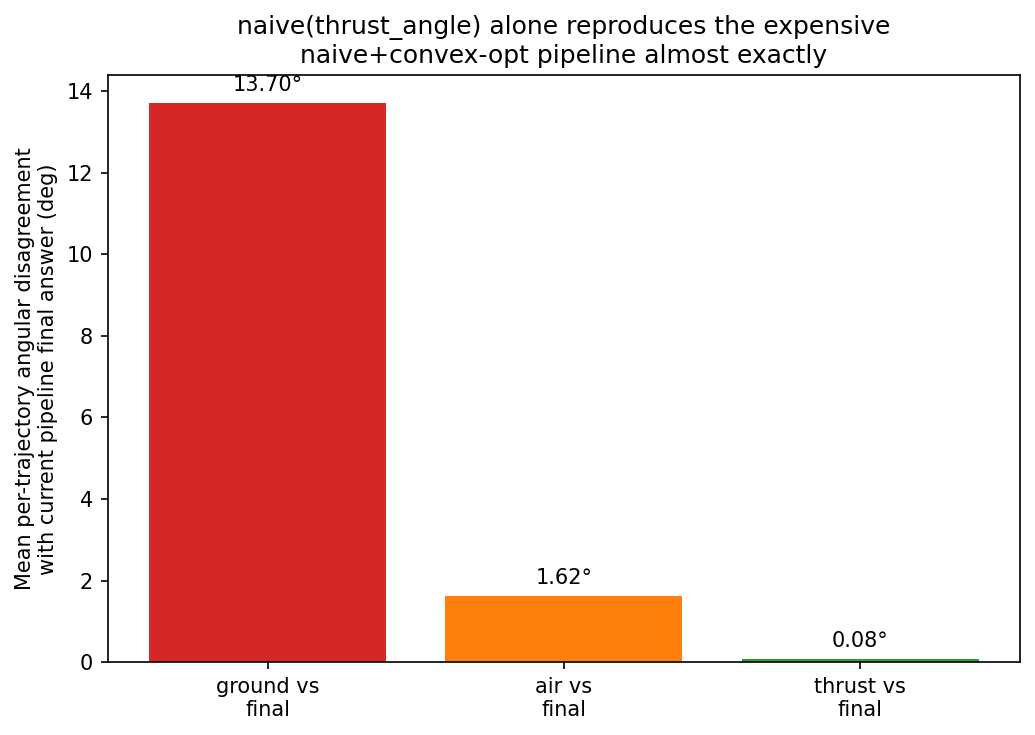

In [7]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
labels = ['ground vs\nfinal', 'air vs\nfinal', 'thrust vs\nfinal']
means = [comparison_df['ground_vs_final_deg'].mean(),
         comparison_df['air_vs_final_deg'].mean(),
         comparison_df['thrust_vs_final_deg'].mean()]
ax.bar(labels, means, color=['tab:red', 'tab:orange', 'tab:green'])
ax.set_ylabel('Mean per-trajectory angular disagreement\nwith current pipeline final answer (deg)')
ax.set_title('naive(thrust_angle) alone reproduces the expensive\nnaive+convex-opt pipeline almost exactly')
for i, v in enumerate(means):
    ax.text(i, v + 0.3, f'{v:.2f}°', ha='center')
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part13_reference_variant_agreement.svg', format='svg')
plt.show()

**Significance:** Naive(thrust_angle), with NO convex-opt at all, reproduces the current expensive naive(ground)+convex-opt pipeline's output to within 0.08 degrees on average across all 2338 currently-trained-on trajectories - essentially exact agreement. naive(air) is nearly as good (1.6 degrees). naive(ground) itself (the current default reference) disagrees with the pipeline's own final answer by 13.7 degrees on average, because on 167 trajectories it picks the wrong global branch outright (>90 degree disagreement with naive(air)), and in 162/167 (97%) of those cases the pipeline's actual final answer (after convex-opt runs) sides with air/thrust, not with naive(ground)'s original guess. In other words: convex-opt's practical effect, the overwhelming majority of the time, is to correct exactly the mistake that a better reference variable would have avoided in the first place.

## 5. Summary

Combining this with Part 9's finding (naive-only, any reference, rejects just 5/3339
candidates - convex-opt causes the other 996 rejections) gives a complete, internally
consistent picture:

- `groundspeed_angle` is a poor reference for naive's global-orientation decision because
  it degenerates (numerically unstable angle) whenever groundspeed magnitude is small -
  the same mechanism Part 3 identified as making the upwind/crosswind regimes hard to
  predict in the first place.
- `airspeed_angle` and `thrust_angle` remain well-defined at near-zero groundspeed (air is
  dominated by the wind vector; thrust reflects the propulsive force the fly is actually
  generating), and using either as naive's reference reproduces the current pipeline's
  final, convex-opt-corrected training data almost exactly (0.08-1.6 degrees mean
  difference) - with no rejection-rate cost, and without the MOSEK dependency.
- Convex-opt's actual, measurable contribution in the current pipeline is therefore almost
  entirely: (a) fixing naive(ground)'s bad global-branch choice on ~7% of trajectories (a
  problem that switching the reference variable solves directly and for free), at the cost
  of (b) introducing spurious jumps that wrongly reject 996 additional, otherwise-fine
  trajectories (Part 9).

RECOMMENDATION FOR THE RESPONSE LETTER: switch `naive_heading_correction`'s reference
column from `groundspeed_angle` to `thrust_angle` (or `airspeed_angle` - nearly
equivalent, 1.7 degree mean difference between them) and drop `convex_opt_heading_correction`
entirely. This is expected to recover the 996 wrongly-rejected trajectories (net dataset
size 2338 -> up to 3334), reproduce the current training labels almost exactly on the
existing 2338, remove the MOSEK licensing dependency from the pipeline altogether, and
require no change to any downstream modeling code. The natural next step, if this is
adopted, is re-running the full pipeline with this change and re-evaluating the ANN on
the larger, cleaner resulting dataset.